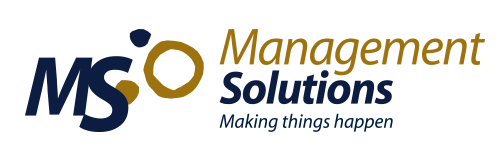

**Contacto**

Guillermo López Gómez: guillermo.lopez.gomez@msspain.com

Sergio Ruiz Bonilla: sergio.ruiz.bonilla@msspain.com

# **MS Challenge: Buscador de Arte Semántico**

Este notebook es un ejemplo de cómo construir un buscador de arte semántico utilizando técnicas de IA Generativa, para resolver el desafío propuesto por Management Solutions. El objetivo es crear un sistema que permita a los usuarios buscar obras de arte utilizando descripciones textuales, y que el sistema pueda entender el contexto y las características de las obras para proporcionar resultados relevantes.

## Objetivos de la Sesión

El objetivo de esta sesión es que el alumno pueda:
1. Comprender los conceptos básicos de la IA Generativa y su aplicación en el ámbito del arte.
2. Entender qué son los embeddings y cómo se utilizan para representar texto e imágenes en un espacio semántico.
3. Aprender a construir un buscador de arte semántico utilizando técnicas de IA Generativa y embeddings.
4. Usar bases de datos vectoriales para almacenar y recuperar información de manera eficiente.
5. Evaluar la efectividad del buscador utilizando métricas de evaluación adecuadas.



In [1]:
import sys
import subprocess
import importlib

# --- Qué instalar para cada nombre "base" de importación
PIP_MAP = {
    "numpy": ["numpy"],
    "torch": ["torch"],
    "matplotlib": ["matplotlib"],
    "PIL": ["pillow"],
    "tqdm": ["tqdm"],
    "pandas": ["pandas"],
    "transformers": ["transformers"],
    "sentence_transformers": ["sentence-transformers"],
    "requests": ["requests"],
    "faiss": ["faiss-cpu"],
    "kagglehub": ["kagglehub"],
    "dotenv": ["python-dotenv"],
    "litellm": ["litellm"],
    "boto3": ["boto3"],
    "botocore": ["botocore"],
    "nest_asyncio": ["nest_asyncio"],
}

def _pip_install(pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])

def ensure_import(code: str, pip_key: str | None = None, optional: bool = False):
    try:
        exec(code, globals())
    except ModuleNotFoundError:
        if optional:
            exec(code, globals())  # el propio code debe manejar el fallback
            return
        if pip_key is None:
            raise
        pkgs = PIP_MAP.get(pip_key, [pip_key])
        print(f"Instalando: {', '.join(pkgs)}")
        _pip_install(pkgs)
        exec(code, globals())

# -------------------------
# stdlib
# -------------------------
ensure_import("import os")
ensure_import("import glob")
ensure_import("import shutil")
ensure_import("import random")
ensure_import("from pathlib import Path")
ensure_import("import base64")
ensure_import("import asyncio")

# -------------------------
# third-party (instala si falta)
# -------------------------
ensure_import("import numpy as np", pip_key="numpy")
ensure_import("import torch", pip_key="torch")
ensure_import("import matplotlib.pyplot as plt", pip_key="matplotlib")
ensure_import("from PIL import Image", pip_key="PIL")
ensure_import("from tqdm.auto import tqdm", pip_key="tqdm")
ensure_import("import pandas as pd", pip_key="pandas")
ensure_import("import requests", pip_key="requests")
ensure_import("from transformers import AutoProcessor, CLIPModel", pip_key="transformers")
ensure_import("from transformers.utils import logging as hf_logging", pip_key="transformers")
ensure_import("from sentence_transformers import SentenceTransformer", pip_key="sentence_transformers")
ensure_import("import faiss", pip_key="faiss")
ensure_import("import kagglehub", pip_key="kagglehub")
ensure_import("from dotenv import load_dotenv, find_dotenv", pip_key="dotenv")
ensure_import("from litellm import completion, acompletion", pip_key="litellm")
ensure_import("import boto3", pip_key="boto3")
ensure_import("from botocore.exceptions import ClientError", pip_key="botocore")
ensure_import("import nest_asyncio", pip_key="nest_asyncio")

# -------------------------
# Colab-only (opcional, no instala)
# -------------------------
ensure_import(
    """
try:
    from google.colab import userdata
except Exception:
    userdata = None
""",
    optional=True,
)

print("Importaciones listas ✅")

Importaciones listas ✅


## Paso 1: Preparación del Dataset

Vamos a utilizar un dataset de obras de arte que contenga imágenes y metadatos de las mismas. En este caso, vamos a utilizar el dataset del [Rijksmuseum](https://www.kaggle.com/datasets/lgmoneda/rijksmuseum) que está disponible públicamente. Vamos a descargarlo y prepararlo para su uso en nuestro buscador de arte semántico.

In [2]:
desired_path = "./dataset"
os.makedirs(desired_path, exist_ok=True)
destination_dir = os.path.join(desired_path, "rijksmuseum")

In [ ]:

path = kagglehub.dataset_download("lgmoneda/rijksmuseum")  # this is the extracted folder

shutil.copytree(path, destination_dir, dirs_exist_ok=True)

print("Dataset guardado en:", destination_dir)

Dataset guardado en: ./dataset/rijksmuseum


Vamos a analizar el dataset para entender su estructura y cómo podemos utilizarlo para entrenar nuestro modelo de IA Generativa. El dataset contiene información sobre las obras de arte, incluyendo el título, el artista, la fecha de creación, la descripción y la imagen.

In [11]:
# Cargar el dataset
dataset_root_dir = os.path.join(destination_dir, "rijksmuseum")
data_path = os.path.join(dataset_root_dir, "metadata.csv")
df = pd.read_csv(data_path)

# Mostremos qué tiene el dataset en sus columnas
print(df.columns)

# Mostrar las carpetas dentro del dataset
folders = [f for f in os.listdir(dataset_root_dir) if os.path.isdir(os.path.join(dataset_root_dir, f))]
print("Carpetas en la subcarpeta del dataset ('rijksmuseum'):", folders)

# Mostrar el número total de elementos dentro de todas las carpetas de la subcarpeta del dataset.
total_items_in_subfolders = sum(len(os.listdir(os.path.join(dataset_root_dir, folder))) for folder in folders)
print("Número total de elementos en todas las carpetas dentro de 'rijksmuseum':", total_items_in_subfolders)
print("Número total de entradas en el dataset (metadata.csv):", len(df))

Index(['Unnamed: 0', 'id', 'title', 'artist', 'date', 'type'], dtype='str')
Carpetas en la subcarpeta del dataset ('rijksmuseum'): ['painting', 'photograph', 'photomechanical print', 'drawing']
Número total de elementos en todas las carpetas dentro de 'rijksmuseum': 24554
Número total de entradas en el dataset (metadata.csv): 24564


El dataset está compuesto por un csv de metadatos y un subsistema de carpetas que contienen las imágenes de las obras de arte. **En el entregable del alumno, se debe incluir** un breve análisis exploratorio del csv de metadatos, mostrando las columnas disponibles y algunas estadísticas básicas sobre el contenido del dataset. Además, se debe mostrar cómo se pueden cargar las imágenes y asociarlas con sus respectivas descripciones para su uso en el modelo de IA Generativa.


## Análisis del dataset

A continuación se muestran los primeros elementos del csv de metadatos. Podemos ver que el csv se compone de estas 6 columnas:

- Unnamed (índice): índice de cada fila del dataset
- id: identificador de cada obra artística. Sirve para poder relacionar los metadátos con la imágenen correspondiente.
- title: título o nombre de la obra de arte.
- artist: Muestra el nombre del creador, artista o fotógrafo de la obra (en los casos en los que se desconoce, aparece como anonymous).
- date: año o periodo estimado en el que se creó la obra.
- type: describe el tipo de obra. Puede ser painting, photomechanical print, photograph o drawing.

In [22]:
df.head()

,Unnamed: 0,id,title,artist,date,type
0,0,SK-A-1849,"The Frederiksplein, Amsterdam, during the Entr...",Otto Eerelman,1898 - 1900,painting
1,1,RP-F-2001-7-230-3,Somersby Church,C.J. Caswell,c. 1884 - in or before 1889,photomechanical print
2,2,RP-F-2001-7-118-17,"Twaalf mannenhoofden in vooraanzicht, gerangsc...",anonymous,c. 1880 - in or before 1893,photomechanical print
3,3,RP-F-F25401-AB,Colossi and sphynx at Wady Saboua - Nubia,Francis Frith,1857,photograph
4,4,RP-F-F25412-R,Roslin Chapel; 'Prentice Pillar,George Washington Wilson,c. 1855 - c. 1862,photograph


### Resument general del dataset

El dataset está compuesto por 24564 entradas y, solamente hay una fila con un valor nulo en la columna artista. Dado que para el proyecto que estamos desarrollando los metadatos no tienen un papel relevante más allá de mostrarle la información de la imágenes recuperadas al usuario, no vamos a realizar ningún cambio.

Por otro lado, debido al gran número de imágenes que forman parte del conjunto de datos, seguramente sea necesario tomar un subconjunto de ellas.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24564 entries, 0 to 24563
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  24564 non-null  int64
 1   id          24564 non-null  str  
 2   title       24564 non-null  str  
 3   artist      24563 non-null  str  
 4   date        24564 non-null  str  
 5   type        24564 non-null  str  
dtypes: int64(1), str(5)
memory usage: 1.1 MB


### Distribución de los distintos tipos de obra

En el siguiente diagrama se muestra la distribución de los distintos tipos de obras que forman parte del dataset.

En primer lugar, vemos que los tipos de obra más presentes son drawing y photomechanical print, por lo que hay un desbalanceo claro entre las distintas clases. Por ello, seguramente nos interese seleccionar un subconjunto de un número fijo de obras de cada tipo para montar nuestra arquitectura.

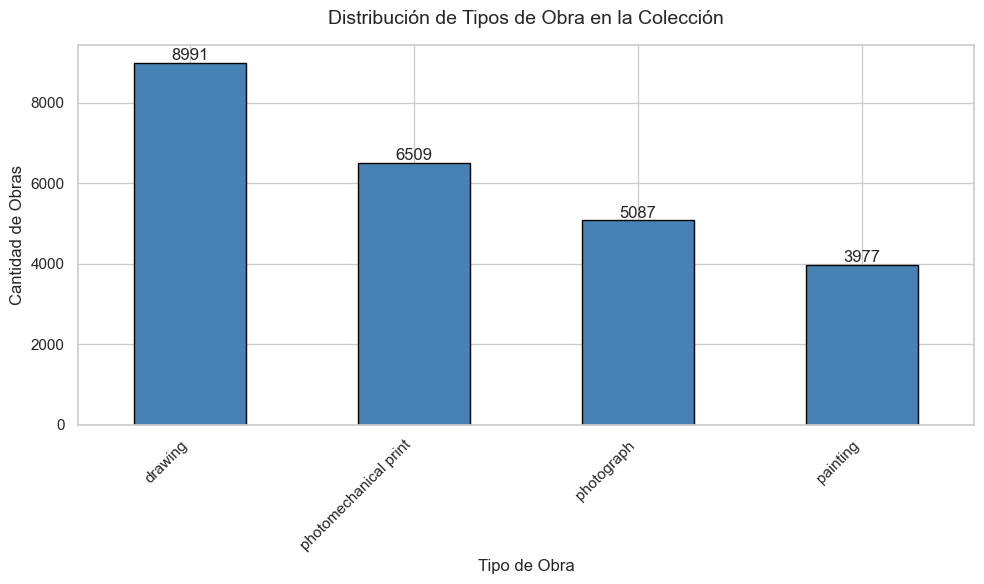

In [23]:
import matplotlib.pyplot as plt
# 1. Configurar el tamaño de la figura para que se vea bien en tu documento
plt.figure(figsize=(10, 6))

# 2. Crear el gráfico de barras a partir del value_counts()
# Utilizamos un color suave y un borde para que se vea elegante
ax = df["type"].value_counts().plot(
    kind='bar', 
    color='steelblue', 
    edgecolor='black'
)

# 3. Personalizar títulos y etiquetas
plt.title('Distribución de Tipos de Obra en la Colección', fontsize=14, pad=15)
plt.xlabel('Tipo de Obra', fontsize=12)
plt.ylabel('Cantidad de Obras', fontsize=12)

# Rotar las etiquetas del eje X para que no se superpongan (ideal si hay textos largos)
plt.xticks(rotation=45, ha='right')

# 4. (Opcional) Poner el número exacto encima de cada barra
for p in ax.patches:
    ax.annotate(str(p.get_height()), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')

# 5. Ajustar el espacio para que no se corten las etiquetas de abajo y guardar
plt.tight_layout()
plt.savefig('distribucion_tipos_real.png', dpi=300) # dpi=300 da calidad para el documento técnico
plt.show()

### Análisis del tamaño de las imágenes

El siguiente código procesa la información de las imágenes para generar un diagrama con la distribución de la relación de aspecto y otro que muestra el ancho y el alto en píxeles de todas las obras artísticas.

En el histograma de la relación de aspecto, se observa que la mayor parte de las imágenes se concentran en valores cercanos a 1. Esto indica que muchas imágenes tienen proporciones casi cuadradas. Sin embargo, el pico principal está ligeramente desplazado hacia valores mayores que 1, aproximadamente entre 1.0 y 1.3, lo que sugiere que predominan imágenes un poco más anchas que altas (orientación horizontal leve). También se aprecia una cola hacia valores mayores, que alcanza aproximadamente hasta 3. Esto indica la existencia de algunas imágenes considerablemente más anchas que altas, aunque son relativamente pocas en comparación con el resto. En cambio, hay menos imágenes con relación de aspecto menor que 1, lo que implica que las imágenes claramente verticales son menos frecuentes en el conjunto.

El diagrama de dispersión entre ancho y alto permite observar cómo se distribuyen las resoluciones reales de las imágenes. La línea roja diagonal representa el caso en el que el ancho y el alto son iguales (imágenes cuadradas). La mayoría de los puntos se sitúan cerca de una línea vertical alrededor de los 1000 píxeles de ancho, lo que indica que muchas imágenes comparten prácticamente el mismo ancho. Esto sugiere que probablemente las imágenes fueron redimensionadas previamente o provienen de una fuente donde el ancho se mantiene constante. En contraste, el alto presenta una variabilidad mucho mayor, extendiéndose desde valores relativamente pequeños hasta alturas cercanas a los 4000 píxeles en algunos casos. Esta variabilidad explica por qué la relación de aspecto presenta cierta dispersión en el histograma.

Además, la dispersión de puntos respecto a la diagonal muestra que la mayoría de las imágenes no son perfectamente cuadradas. Muchos puntos se encuentran por encima o por debajo de la línea, indicando que el alto y el ancho difieren de forma notable en varios casos. También se pueden identificar algunos valores atípicos (outliers), especialmente imágenes con alturas muy grandes o relaciones de aspecto extremas.

En conjunto, el análisis sugiere que el dataset está dominado por imágenes con ancho relativamente constante y altura variable, lo que produce una distribución de relaciones de aspecto centrada cerca de 1 pero con cierta inclinación hacia formatos horizontales. La presencia de algunos valores extremos indica que existe cierta heterogeneidad en las dimensiones de las imágenes, aunque la mayoría se mantiene dentro de un rango moderado de proporciones. Esto puede ser relevante si se planea utilizar el conjunto para tareas de visión por computadora, ya que podría requerirse un proceso de normalización o redimensionamiento para mantener consistencia en las entradas del modelo


Se encontraron 24554 imágenes en total.


100%|██████████| 24554/24554 [00:00<00:00, 24833.74it/s]


Error leyendo ./dataset/rijksmuseum/rijksmuseum/drawing/RP-T-1940-571.jpg: cannot identify image file './dataset/rijksmuseum/rijksmuseum/drawing/RP-T-1940-571.jpg'

--- Resumen Estadístico ---
              width        height  aspect_ratio  resolution_megapixels
count  24553.000000  24553.000000  24553.000000           24553.000000
mean     999.310105    995.290799      1.152930               0.993551
std       18.861065    368.118089      0.443721               0.363799
min      194.000000    123.000000      0.077600               0.123000
25%     1000.000000    681.000000      0.765111               0.681000
50%     1000.000000    822.000000      1.216545               0.821000
75%     1000.000000   1307.000000      1.468429               1.307000
max     1000.000000   3894.000000      8.130081               3.060684


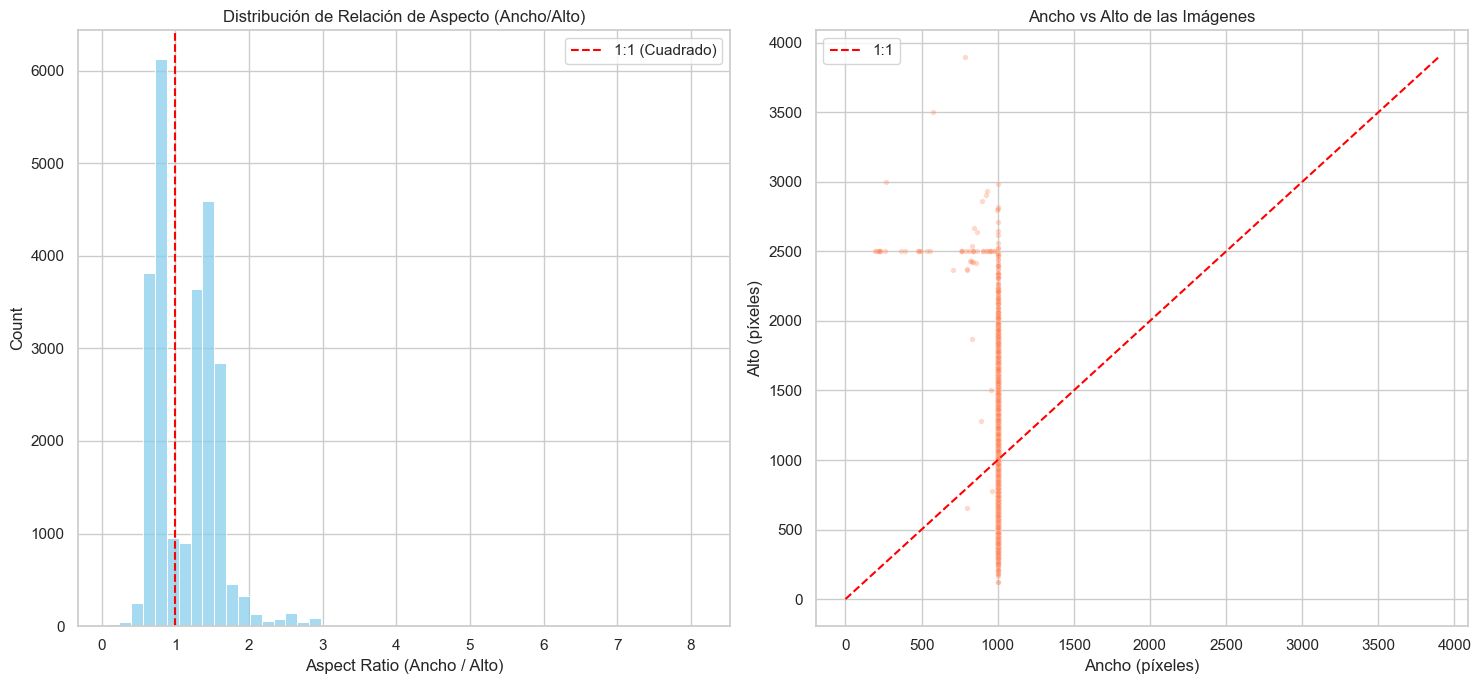

In [ ]:
import os
import glob
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# 1. RUTA A TUS IMÁGENES (Cámbiala por la tuya)
IMAGE_FOLDER = "./dataset/rijksmuseum/" 
extensions = ["*.jpg", "*.jpeg", "*.png", "*.tif", "*.tiff", "*.JPG", "*.PNG"]

image_paths = []
for ext in extensions:
    # glob.glob con recursive=True buscará en todas las subcarpetas
    rutas = glob.glob(os.path.join(IMAGE_FOLDER, f"**/{ext}"), recursive=True)
    image_paths.extend(rutas)

print(f"Se encontraron {len(image_paths)} imágenes en total.")
# 2. EXTRAER DIMENSIONES
data = []
for path in tqdm(image_paths):
    try:
        # Abrimos la imagen sin cargarla en memoria RAM completamente
        with Image.open(path) as img:
            width, height = img.size
            data.append({"filename": os.path.basename(path), "width": width, "height": height})
    except Exception as e:
        print(f"Error leyendo {path}: {e}")

df = pd.DataFrame(data)

# 3. CÁLCULO DE MÉTRICAS (Aspect Ratio y Resolución)
df['aspect_ratio'] = df['width'] / df['height']
df['resolution_megapixels'] = (df['width'] * df['height']) / 1_000_000

# Guardamos el resumen estadístico
print("\n--- Resumen Estadístico ---")
print(df.describe())
df.to_csv("analisis_dimensiones_rijksmuseum.csv", index=False)

# 4. GENERACIÓN DE GRÁFICOS PARA TU DOCUMENTO TÉCNICO
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Gráfico 1: Histograma de Aspect Ratio
sns.histplot(df['aspect_ratio'], bins=50, ax=axes[0], color='skyblue')
axes[0].axvline(1.0, color='red', linestyle='--', label='1:1 (Cuadrado)')
axes[0].set_title('Distribución de Relación de Aspecto (Ancho/Alto)')
axes[0].set_xlabel('Aspect Ratio (Ancho / Alto)')
axes[0].legend()

# Gráfico 2: Scatter Plot (Ancho vs Alto)
sns.scatterplot(x='width', y='height', data=df, alpha=0.3, ax=axes[1], color='coral', s=15)
# Línea de proporción cuadrada
max_val = max(df['width'].max(), df['height'].max())
axes[1].plot([0, max_val], [0, max_val], color='red', linestyle='--', label='1:1')
axes[1].set_title('Ancho vs Alto de las Imágenes')
axes[1].set_xlabel('Ancho (píxeles)')
axes[1].set_ylabel('Alto (píxeles)')
axes[1].legend()


plt.tight_layout()
plt.savefig('rijksmuseum_dimension_analysis.png', dpi=300)
plt.show()

 Cogería un número X determinado de cada clase. De drawing hay demasiados y muchos son parecidos y así tenemos representación por igual de todo tipo de obras.

 Se puede usar jina-clip-v2, multilingue bastante tamaño de imágenes y tiene buena pinta yo creo. El ppading de las imágenes seguramente sea mejor incluir bandas negras que recortar.

 Otra opción es dividir la imágen en bloques de 512 y luego unirlos pero igual es demasiado yo pasaría.


***
## **LLMs, Embeddings y Capacidades de Visión**
En esta sección vamos a explorar los conceptos de embeddings y cómo se utilizan para representar texto e imágenes en un espacio semántico. También vamos a discutir las capacidades de visión de los modelos de IA Generativa y cómo pueden ser utilizadas para entender el contenido visual de las obras de arte.


### **LLMs (Large Language Models)**

Los LLMs son modelos de lenguaje a gran escala que han sido entrenados con grandes cantidades de texto para aprender a generar texto coherente y relevante. Estos modelos pueden ser utilizados para una variedad de tareas, incluyendo la generación de texto, la traducción automática, el resumen de texto, entre otras. En el contexto del buscador de arte semántico, los LLMs pueden ser utilizados para entender las descripciones textuales de las obras de arte y generar respuestas relevantes basadas en esas descripciones.




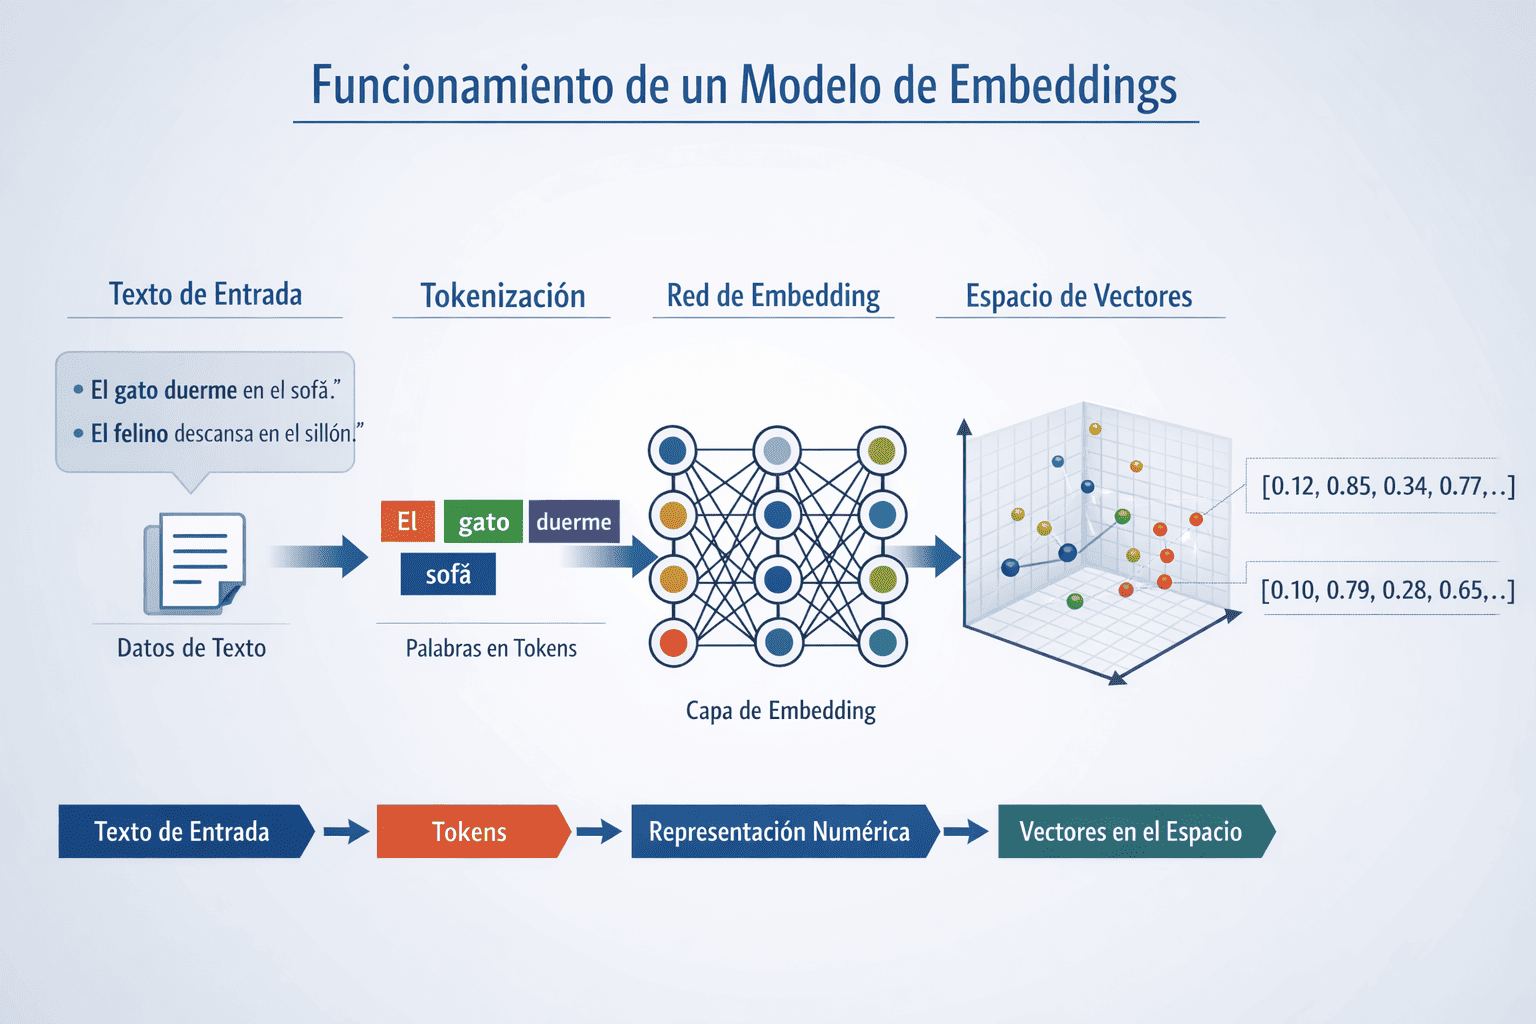

### **Embeddings**

Un embedding es una **representación numérica de un objeto**, como un texto o una imagen, en un espacio vectorial. Los embeddings nos permiten introducir estos "objetos" en modelos de aprendizaje automático y realizar operaciones matemáticas sobre ellos.

Un embedding es obtenido a través de un modelo de embeddings. Estos modelos pueden ser entrenados para aprender a representar texto e imágenes de manera que las relaciones semánticas entre ellos se mantengan en el espacio vectorial. Por ejemplo, si dos obras de arte tienen descripciones similares, sus embeddings estarán cerca en el espacio vectorial.

**¿Qué hay debajo de un modelo de embeddings?**

Un modelo de embeddings generalmente se basa en una arquitectura de red neuronal, como una red neuronal recurrente (RNN) o una red neuronal convolucional (CNN). El modelo se entrena utilizando un conjunto de datos de texto e imágenes, y aprende a mapear cada objeto a un vector en el espacio semántico. Durante el entrenamiento, el modelo ajusta sus pesos para minimizar la distancia entre los embeddings de objetos similares y maximizar la distancia entre los embeddings de objetos diferentes.

**Vamos a obtener embeddings de un texto de ejemplo, usando un modelo de embeddings preentrenado de [sentence transformers](https://sbert.net/).**

In [5]:
# Silenciar logs de Hugging Face + transformers
hf_logging.set_verbosity_error()

print("Descargando modelo...")
st_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2",
    cache_folder=None  # cache por defecto
)

texts = [
    "Hello from Madrid! This is an example sentence to embed.",
    "Here is a second sentence, just to show batching."
]

embeddings = st_model.encode(
    texts,
    normalize_embeddings=True,
    batch_size=32,
    show_progress_bar=False
)

print("Forma de los embeddings:", embeddings.shape)
print("Primer embedding (primeras 10 dimensioness):", embeddings[0][:10])

Descargando modelo...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Forma de los embeddings: (2, 384)
Primer embedding (primeras 10 dimensioness): [ 0.01512322  0.03388584  0.0493029   0.02839654  0.04400937  0.00100489
  0.04316365 -0.00289189  0.01863117 -0.08025531]


En la celda anterior hemos generado embeddings para **2 frases** y la salida nos confirma su forma:

- `Embeddings shape: (2, 384)`  
  Esto significa: **2 textos → 2 vectores**, cada uno en un espacio de **384 dimensiones** (propio del modelo `all-MiniLM-L6-v2`).
- `First embedding (first 10 dims): [...]`  
  Es normal ver **valores positivos y negativos**: cada dimensión no tiene un significado “humano” aislado, sino que el **patrón completo del vector** codifica la semántica.

## **Embeddings multimodales**

Hasta ahora, el espacio semántico contenía solo representaciones de texto.

**Un embedding multimodal es una representación vectorial de distintos tipos de datos (por ejemplo, texto e imágenes) en un mismo espacio vectorial compartido.**
***

**¿Por qué es tán potente el embedding multimodal?**

Estos embeddings nos permiten recuperar información relevante de cualquier tipo. En bases de conocimiento de empresas, donde ese conocimiento puede estar alojado en cualquier tipo de formato,  nos permite recuperar esa información relevante independientemente del formato.

La idea central es el **alineamiento cross-modal**:
- Los textos que describen una imagen deberían quedar cerca del embedding de esa imagen.
- Los textos no relacionados deberían quedar lejos.

Estos modelos se suelen entrenar con **aprendizaje contrastivo**: para un lote de pares (imagen, texto), el modelo “empuja” los pares correctos a alta similitud y “separa” los incorrectos.

---

### ¿Qué modelo vamos a utilizar?

**[CLIP](https://openai.com/es-ES/index/clip/) (*Contrastive Language–Image Pretraining*)** es un modelo entrenado para alinear imágenes y textos: usa un encoder de imagen y un encoder de texto que proyectan ambos a un mismo espacio (en este caso, de 512 dimensiones), optimizando una pérdida contrastiva sobre pares imagen–texto. El resultado es que podemos hacer tareas como *image-text retrieval* o *zero-shot classification* comparando embeddings con similitud coseno.

En la siguiente celda aplicaremos CLIP a una imagen y varios prompts, y veremos cuál prompt queda más “cerca” de la imagen en el espacio vectorial.

In [6]:
model_id = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_id)
processor = AutoProcessor.from_pretrained(model_id)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device).eval()

# ---- cargar imagen ----
url = "https://upload.wikimedia.org/wikipedia/commons/3/3f/Fronalpstock_big.jpg"
r = requests.get(url, stream=True, headers={"User-Agent": "Mozilla/5.0"}, timeout=30)
r.raise_for_status()
r.raw.decode_content = True
image = Image.open(r.raw).convert("RGB")

# ---- prompts de texto (puede ser una sola cadena o una lista) ----
texts = [
    "una foto de montañas",
    "un perro jugando en el parque",
    "un paisaje escénico con un lago",
]

# ---- preprocesado conjunto ----
inputs = processor(
    text=texts,
    images=image,
    return_tensors="pt",
    padding=True,
)

# mover tensores al dispositivo
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    # Cuando pasas texto + imagen, CLIPModel devuelve ambas incrustaciones
    outputs = model(**inputs)
    incrustaciones_imagen = outputs.image_embeds  # (batch_image=1, 512)
    incrustaciones_texto = outputs.text_embeds    # (batch_text=len(texts), 512)

    # normalizar para similitud coseno
    incrustaciones_imagen = incrustaciones_imagen / incrustaciones_imagen.norm(dim=-1, keepdim=True)
    incrustaciones_texto = incrustaciones_texto / incrustaciones_texto.norm(dim=-1, keepdim=True)

    # similitud coseno (texto x imagen)
    sims = incrustaciones_texto @ incrustaciones_imagen.T  # (len(texts), 1)

print("Forma de los embeddings de imagen:", incrustaciones_imagen.shape)
print("Forma de los embeddings de texto:", incrustaciones_texto.shape)
print("Primer embedding de imagen (primeras 10 dims):", incrustaciones_imagen[0, :10].detach().cpu())
print("\nSimilitudes coseno:")
for t, s in zip(texts, sims.squeeze(1).detach().cpu().tolist()):
    print(f"  {s: .4f}  |  {t}")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Forma de los embeddings de imagen: torch.Size([1, 512])
Forma de los embeddings de texto: torch.Size([3, 512])
Primer embedding de imagen (primeras 10 dims): tensor([-0.0314,  0.0627, -0.0198,  0.0196,  0.0092, -0.0348,  0.0674, -0.0009,
        -0.0032,  0.0515])

Similitudes coseno:
   0.2323  |  una foto de montañas
   0.1258  |  un perro jugando en el parque
   0.2297  |  un paisaje escénico con un lago


## Paso 2: Ingesta (Imagen → Embeddings multimodales → Índice vectorial)

En el challenge, la solución se divide en **Ingesta** y **Recuperación**.  
Ahora vamos a implementar la parte de **Ingesta** con el pipeline:

**Imagen → Embeddings (CLIP) → Vector DB / índice vectorial**

Para simplificar el desarrollo y reducir el tiempo de procesamiento, vamos a obtener un subset de forma aleatoria de 2000 fotos de las 25000 originales. Para ello:
- **Selección de fotos:** vamos a seleccionar 2000 fotos aleatorias de las subcarpetas y vamos a insertarlas todas juntas en una nueva carpeta.
- **Filtrado de metadatos:** Vamos a filtrar el dataframe de metadatos para que incluya solo las imágenes seleccionadas

In [12]:
# 1. Directorios
directorio_raiz_dataset = os.path.join(destination_dir, "rijksmuseum")
directorio_imagenes_seleccionadas = os.path.join(desired_path, "selected_images")
os.makedirs(directorio_imagenes_seleccionadas, exist_ok=True)

# 2. Recoger todas las rutas .jpg de las carpetas
todos_los_archivos_imagen = []
for carpeta in folders:
    ruta_carpeta = os.path.join(directorio_raiz_dataset, carpeta)
    todos_los_archivos_imagen.extend(glob.glob(os.path.join(ruta_carpeta, "*.jpg")))

print(f"Se encontraron {len(todos_los_archivos_imagen)} archivos .jpg en total.")

# 3. Seleccionar hasta 2000 (si hay menos, coge todas)
num_imagenes_a_seleccionar = 2
selected_image_paths = (
    todos_los_archivos_imagen
    if len(todos_los_archivos_imagen) <= num_imagenes_a_seleccionar
    else random.sample(todos_los_archivos_imagen, num_imagenes_a_seleccionar)
)

print(f"Se seleccionaron {len(selected_image_paths)} imágenes.")

# 4. Copiar al directorio destino
for ruta_img in selected_image_paths:
    shutil.copy2(ruta_img, os.path.join(directorio_imagenes_seleccionadas, os.path.basename(ruta_img)))

print(f"Se copiaron correctamente {len(selected_image_paths)} imágenes en {directorio_imagenes_seleccionadas}")

Se encontraron 24554 archivos .jpg en total.
Se seleccionaron 2 imágenes.
Se copiaron correctamente 2 imágenes en ./dataset/selected_images


Las fotos han sido seleccionadas e introducidas en "/selected_images" correctamente. Vamos ahora a filtrar el dataframe.



In [5]:
# Extraer los IDs de imagen a partir de selected_image_paths
# El 'id' en el dataframe es el nombre del archivo sin extensión
ids_imagen_copiados = []
for ruta_img in selected_image_paths:
    nombre_archivo = os.path.basename(ruta_img)
    id_imagen = os.path.splitext(nombre_archivo)[0]
    ids_imagen_copiados.append(id_imagen)

# Filtrar el DataFrame original para incluir solo las imágenes seleccionadas
df = df[df["id"].isin(ids_imagen_copiados)].copy()

print("Longitud del DataFrame:", len(df))


Longitud del DataFrame: 2


Con estas dos celdas ya tenemos nuestros datos preparados para poder pasar las imágenes a CLIP.

Como base de datos vectorial, vamos a usar [FAISS](https://github.com/facebookresearch/faiss/wiki). Un buen análisis que puede hacer el alumno en el documento técnico de entrega es **Por qué FAISS no es una BBDD que se use normalmente en entornos escalables y de producción, indicando cuáles son las alternativas comunes para estos casos.**

In [9]:
BATCH = 32

trozos_emb = []
id2path = []

# Recorremos las rutas en lotes para no cargar todas las imágenes a la vez
for i in tqdm(range(0, len(selected_image_paths), BATCH), desc="Lotes de embeddings"):
    rutas_lote = selected_image_paths[i : i + BATCH]

    imagenes = []
    rutas_ok = []
    for p in rutas_lote:
        try:
            # Abrimos y convertimos a RGB; si falla, saltamos esa imagen
            with Image.open(p) as im:
                imagenes.append(im.convert("RGB"))
            rutas_ok.append(p)
        except Exception:
            pass

    if not imagenes:
        continue

    # Preprocesado a tensores y envío al dispositivo (CPU/GPU)
    valores_pixel = processor(images=imagenes, return_tensors="pt")["pixel_values"].to(device)

    with torch.no_grad():  # inferencia sin gradientes
        out = model.get_image_features(pixel_values=valores_pixel)

        # Compatibilidad con distintas salidas (según el modelo)
        if hasattr(out, "pooler_output") and out.pooler_output is not None:
            feats = out.pooler_output
        elif isinstance(out, (tuple, list)):
            feats = out[0]
        else:
            feats = out

        # Normalización L2 para que el producto escalar sea coseno
        feats = feats / feats.norm(dim=-1, keepdim=True)

    # Guardamos embeddings y el mapeo índice -> ruta
    trozos_emb.append(feats.cpu().numpy().astype("float32"))
    id2path.extend(rutas_ok)

# Apilamos todos los lotes en una única matriz (N x D)
incrustaciones_img = np.vstack(trozos_emb).astype("float32")
d = incrustaciones_img.shape[1]

# Índice FAISS de similitud por producto escalar (con vectores normalizados = coseno)
index = faiss.IndexFlatIP(d)
index.add(incrustaciones_img)

print("Embeddings:", incrustaciones_img.shape)
print("Vectores FAISS:", index.ntotal)

Lotes de embeddings:   0%|          | 0/63 [00:00<?, ?it/s]

Embeddings: (2000, 512)
Vectores FAISS: 2000


### Recapitulación: ¿qué significa “Ingesta” en un flujo de RAG?

En una solución tipo RAG / buscador semántico, la ingesta es el proceso de convertir nuestros objetos (documentos, imágenes, trozos de texto, etc.) en vectores y guardarlos en un índice vectorial para poder recuperarlos luego por similitud.

En nuestro caso, la ingesta ha hecho (implícitamente) estas 4 cosas:

1. **Selección de elementos**  
   Elegimos un subconjunto de imágenes para reducir coste y tiempo (2000 en vez de 25k).

2. **Transformación a embeddings (CLIP)**  
   Pasamos cada imagen por el encoder de CLIP para obtener un vector denso en un espacio semántico compartido.

3. **Normalización del embedding**  
   Al normalizar a norma 1 (`v / ||v||`), el producto interno (Inner Product) se comporta como similitud coseno.  
   Esto es clave porque el índice que usamos es `IndexFlatIP` (IP = Inner Product).

4. **Indexación + mapeo a los originales**  
   Insertamos los vectores en FAISS y mantenemos un mapeo (por ejemplo `id2path`) para poder volver del “índice i” → “imagen real + metadatos”.

## Paso 3: Recuperación (Consulta en texto → búsqueda kNN en FAISS → resultados)

La recuperación consiste en:

1. Convertir la consulta del usuario (texto) a un embedding **usando el mismo modelo (IMPORTANTE)**.
2. Buscar los k vecinos más cercanos en el índice vectorial (FAISS).
3. Traducir los IDs devueltos por FAISS a elementos reales (paths + metadatos) y mostrarlos.

### ¿Qué está pasando “matemáticamente”?

- Tenemos un conjunto de vectores `{x_i}` (embeddings de imágenes) en un espacio de dimensión `d`.
- Para una query `q` (embedding del texto), buscamos:

$$
\operatorname{topK}(q) = \arg\max_{i} \; \text{sim}(q, x_i)
$$

Como estamos usando `IndexFlatIP` y **normalizamos** los vectores, la similitud es aproximadamente:

- `sim(q, x) = q · x`  (producto interno)
- y si ambos están normalizados, equivale a **cosine similarity**.

> `IndexFlatIP` es la versión más simple (búsqueda exacta por fuerza bruta).  
> Para docencia está perfecto: es fácil de entender y da resultados correctos, aunque no escala tan bien.

In [10]:
def _text_embedding_clip(text: str):
    enc = processor(text=[text], return_tensors="pt", padding=True, truncation=True)
    enc = {k: v.to(device) for k, v in enc.items()}

    with torch.no_grad():
        out = model.get_text_features(**enc)

        # Compatibilidad: a veces 'out' no es tensor sino un output con pooler_output
        if hasattr(out, "pooler_output") and out.pooler_output is not None:
            feats = out.pooler_output
        elif isinstance(out, (tuple, list)):
            feats = out[0]
        else:
            feats = out

        feats = feats / feats.norm(dim=-1, keepdim=True)

    return feats.detach().cpu().numpy().astype("float32")

def buscar_por_texto(query: str, k: int = 5):
    """Devuelve (scores, paths, ids_df) ordenados por similitud."""
    q = _text_embedding_clip(query)
    scores, idxs = index.search(q, k)

    scores = scores[0].tolist()
    idxs = idxs[0].tolist()

    paths = [id2path[i] for i in idxs]
    img_ids = [os.path.splitext(os.path.basename(p))[0] for p in paths]
    return scores, paths, img_ids

def mostrar_resultados(query: str, k: int = 5):
    scores, paths, img_ids = buscar_por_texto(query, k=k)

    # (opcional) asegurar tipos por si el CSV trae id numérico
    if "id" in df.columns:
        df["id"] = df["id"].astype(str)

    plt.figure(figsize=(3*k, 3))
    for j, (s, p, img_id) in enumerate(zip(scores, paths, img_ids), start=1):
        plt.subplot(1, k, j)
        plt.imshow(Image.open(p).convert("RGB"))
        plt.axis("off")

        # metadatos (si existen)
        titulo, autor = "", ""
        if "id" in df.columns and (df["id"] == img_id).any():
            row = df[df["id"] == img_id].iloc[0]
            if "title" in df.columns: titulo = str(row.get("title", ""))
            if "principalOrFirstMaker" in df.columns: autor = str(row.get("principalOrFirstMaker", ""))

        plt.title(f"{s:.3f}\n{titulo}\n{autor}", fontsize=9)

    plt.suptitle(query)
    plt.show()

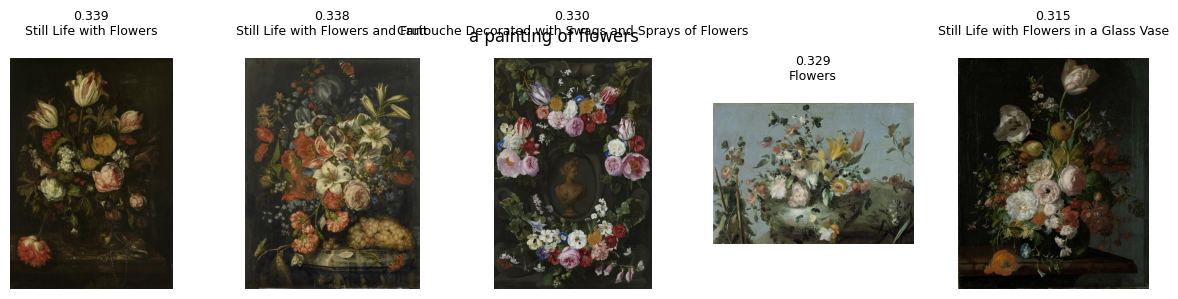

In [13]:
# mostrar_resultados("a portrait of a woman", k=5)
# mostrar_resultados("a ship at sea", k=5)
mostrar_resultados("a painting of flowers", k=5)

---
## Pipeline 2: Imagen → VLM (Amazon Nova 2 Lite en Bedrock) → Texto → Embeddings (SentenceTransformers)

En el documento técnico se proponen 2 alternativas para la ingesta. Ya hemos implementado:

**Imagen → Embeddings (multimodal) → FAISS**

Ahora vamos a implementar la alternativa:

**Imagen → VLM → Texto → Embeddings de texto → FAISS**

Usaremos:
- **LiteLLM** como interfaz unificada.
- **Amazon Nova 2 Lite** para generar descripciones. **IMPORTANTE: Este modelo es de pago en la API de Amazon Bedrock. Para Modelos de uso gratuito, se puede usar la [API gratuita de Google Gemini](https://ai.google.dev/gemini-api/docs/pricing)**
- **Sentence Transformers** como modelo de embeddings de texto

### ¿Qué cambia en este Pipeline 2?

En el Pipeline 1 indexábamos directamente **embeddings multimodales** (imagen → vector).  
En este Pipeline 2 añadimos un paso intermedio: **convertimos la imagen en texto**, y luego indexamos **embeddings de texto**.

El flujo completo es:

1. **Imagen → VLM (Nova 2 Lite)**  
   El modelo “mira” la imagen y genera una **descripción en lenguaje natural** (caption / resumen).

2. **Texto → Embeddings (SentenceTransformers)**  
   Convertimos esa descripción a un vector en un espacio semántico de texto.

3. **Embeddings → FAISS**  
   Indexamos los vectores para búsqueda rápida por similitud.

¿Por qué hacer esto si ya teníamos CLIP?

- **Explicabilidad**: puedes ver la descripción y entender por qué una imagen “aparece” como resultado.
- **Flexibilidad del lenguaje**: las descripciones pueden capturar detalles (objetos, estilo, mood) que el embedding directo a veces no hace tan explícitos.
- **Trade-off**: suele ser **más caro** y **más lento** (hay una llamada al VLM por imagen), pero puede mejorar la recuperación en ciertos casos.


***
### 1) Generación de descripciones de las imágenes

Aquí usamos un modelo visión-lenguaje para convertir cada imagen en una breve descripción.
Piensa en ello como un *captioning* guiado: el modelo “resume” lo que ve en texto.

El resultado es un dataset intermedio del tipo:

- `imagen → descripción`

Este paso es clave porque determina el “vocabulario” con el que luego buscaremos.  
Si las descripciones son pobres o inconsistentes, la recuperación posterior también lo será.

In [14]:
import os
import base64
import asyncio
from tqdm.asyncio import tqdm
from mistralai import Mistral
import time

# --- Configuración Mistral ---
MISTRAL_API_KEY = "s2UfxP40Sr4S5YPBG90Rh5kTxkaYijl2"
# Usamos Pixtral, el modelo con capacidades de visión
MISTRAL_MODEL = "pixtral-12b-2409" 

# Inicializamos el cliente asíncrono
client = Mistral(api_key=MISTRAL_API_KEY)

# Helpers
def _b64_image_url(image_path: str) -> str:
    with open(image_path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode("utf-8")
    # Mistral acepta el formato estándar de Data URL
    return f"data:image/jpeg;base64,{b64}"

async def describe_image_mistral_async(image_path: str) -> str:
    image_url = _b64_image_url(image_path)

    max_retries = 3
    base_sleep_s = 0.8

    for attempt in range(1, max_retries + 1):
        try:
            # Usamos la versión asíncrona del chat de Mistral
            resp = await client.chat.complete_async(
                model=MISTRAL_MODEL,
                messages=[
                    {
                        "role": "user",
                        "content": [
                            {
                                "type": "text",
                                "text": (
                                    "Act as an art history expert. Your task is to analyze this image for an artwork information retrieval system. "
                                    "Begin the first sentence by explicitly identifying whether the work is a painting, a photograph, a photomechanical print, or a picture. "
                                    "Next, fluidly describe the main subject, the spatial composition, and the use of light. "
                                    "Integrate into the narrative details about the color palette, the technique (such as the type of brushstroke or photographic grain), "
                                    "and especially the atmosphere or mood it conveys. "
                                    "Use specialized art vocabulary and make sure to mention key objects or symbols. "
                                    "At the end, add a comma-separated list of keywords including specific objects, symbols, or iconographical details."
                                ),
                            },
                            {"type": "image_url", "image_url": image_url},
                        ],
                    }
                ],
                temperature=0.2,
                max_tokens=500  # Reducido de 5000 a 500 (suficiente para una descripción corta)
            )
            return resp.choices[0].message.content.strip()
        except Exception as e:
            if attempt == max_retries:
                print(f"Error final en {image_path}: {e}")
                raise
            await asyncio.sleep(base_sleep_s * (2 ** (attempt - 1)))

# Generar descripciones con concurrencia
descriptions = []
desc_paths = []

async def _run_concurrent(image_paths, max_concurrency: int = 100):
    # Nota: Ojo con el límite de rate limit de Mistral al usar 100 de concurrencia
    sem = asyncio.Semaphore(max_concurrency)

    async def _one(p: str):
        async with sem:
            d = await describe_image_mistral_async(p)
            return p, d

    tasks = [asyncio.create_task(_one(p)) for p in image_paths]
    pbar = tqdm(total=len(tasks), desc=f"Describiendo con Pixtral (concurrencia={max_concurrency})")

    for fut in asyncio.as_completed(tasks):
        try:
            p, d = await fut
            descriptions.append(d)
            desc_paths.append(p)
            time.sleep(30)
        except Exception:
            pass
        finally:
            pbar.update(1)

    pbar.close()

# Ejecución (en entornos con event loop como Colab/Jupyter)
await _run_concurrent(selected_image_paths, max_concurrency=10) # Bajamos a 10 por precaución con el Rate Limit

print("\n--- Proceso finalizado ---")
print("Descripciones generadas:", len(descriptions))
if descriptions:
    print("Ejemplo:\n", descriptions[0])

Describiendo con Pixtral (concurrencia=10):  50%|█████     | 1/2 [00:03<00:03,  3.07s/it]

Error final en ./dataset/rijksmuseum/rijksmuseum/drawing/RP-T-1968-35.jpg: API error occurred: Status 429. Body: {"object":"error","message":"Rate limit exceeded","type":"rate_limited","param":null,"code":"1300"}


Describiendo con Pixtral (concurrencia=10): 100%|██████████| 2/2 [00:34<00:00, 17.18s/it]


--- Proceso finalizado ---
Descripciones generadas: 1
Ejemplo:
 This image is a photomechanical print, likely a carte-de-visite or cabinet card, a popular format for portraiture in the 19th century.

The main subject is a distinguished gentleman, captured in a three-quarter view that emphasizes his dignified and composed demeanor. His facial features are rendered with meticulous attention to detail, highlighting the textural nuances of his mustache, receding hairline, and the fine lines on his forehead, which suggest age and experience. The spatial composition is centered and symmetrical, with the oval framing device drawing the viewer’s focus directly to his visage, a common technique in portrait photography of the era to convey importance and gravitas.

The use of light is soft yet deliberate, creating a subtle chiaroscuro effect that gently models the contours of his face and clothing. The tonal range is limited to grayscale, characteristic of the monochromatic palette of photomech

### 2) Indexación semántica de las descripciones

Una vez tenemos una descripción por imagen, tratamos esas descripciones como si fueran documentos:

- Convertimos cada descripción en un **vector semántico** (embedding de texto).
- Guardamos esos vectores en un índice para búsquedas rápidas por similitud.

Esto permite consultas como “paisaje nocturno con luces” o “retrato con fondo neutro” sin depender de palabras exactas:  
la búsqueda se basa en significado, no en coincidencias literales.

In [12]:
# Generamos embeddings em batches de 32 con nuestro modelo
desc_emb = st_model.encode(
    descriptions,
    normalize_embeddings=True,
    batch_size=32,
    show_progress_bar=True,
).astype("float32")

d = desc_emb.shape[1]
index_desc = faiss.IndexFlatIP(d)
index_desc.add(desc_emb)

print("Index (descripciones) listo ✅ | N =", index_desc.ntotal, "| dim =", d)

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Index (descripciones) listo ✅ | N = 2000 | dim = 384


### 3) Recuperación y visualización de resultados

En consulta:

1. La query del usuario se convierte al mismo espacio vectorial de texto.
2. Se recuperan las descripciones más cercanas del índice (top-k).
3. Se muestran las imágenes asociadas a esas descripciones.

La ventaja principal de este enfoque es que puedes inspeccionar la **descripción recuperada** para entender el resultado y depurar:
- si la descripción no refleja bien la imagen, ajustas el prompt / estrategia de descripción;
- si la descripción está bien pero no recupera, ajustas el modelo de embeddings o el índice.

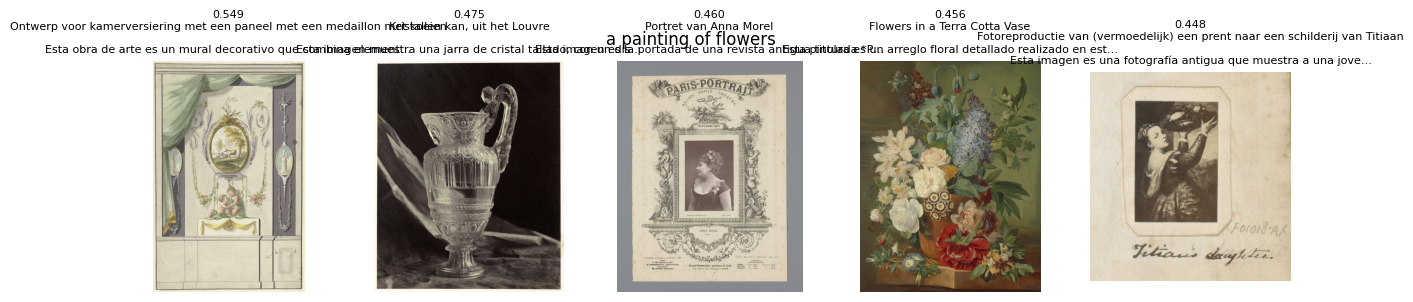

In [13]:
def _text_embedding_st(text: str):
    v = st_model.encode([text], normalize_embeddings=True).astype("float32")
    return v

def buscar_por_texto_descripciones(query: str, k: int = 5):
    q = _text_embedding_st(query)
    scores, idxs = index_desc.search(q, k)

    scores = scores[0].tolist()
    idxs = idxs[0].tolist()

    paths = [desc_paths[i] for i in idxs]
    img_ids = [os.path.splitext(os.path.basename(p))[0] for p in paths]
    return scores, paths, img_ids, idxs

def mostrar_resultados_descripciones(query: str, k: int = 5):
    scores, paths, img_ids, idxs = buscar_por_texto_descripciones(query, k=k)

    if "id" in df.columns:
        df["id"] = df["id"].astype(str)

    plt.figure(figsize=(3*k, 3))
    for j, (s, p, img_id, idx) in enumerate(zip(scores, paths, img_ids, idxs), start=1):
        plt.subplot(1, k, j)
        plt.imshow(Image.open(p).convert("RGB"))
        plt.axis("off")

        titulo, autor = "", ""
        if "id" in df.columns and (df["id"] == img_id).any():
            row = df[df["id"] == img_id].iloc[0]
            if "title" in df.columns: titulo = str(row.get("title", ""))
            if "principalOrFirstMaker" in df.columns: autor = str(row.get("principalOrFirstMaker", ""))

        desc_short = (descriptions[idx][:60] + "…") if descriptions else ""
        plt.title(f"{s:.3f}\n{titulo}\n{autor}\n{desc_short}", fontsize=8)

    plt.suptitle(query)
    plt.show()

# Ejemplo
mostrar_resultados_descripciones("a painting of flowers", k=5)


###  Recuperación y visualización de resultados

En consulta:

1. La query del usuario se convierte al mismo espacio vectorial de texto.
2. Se recuperan las descripciones más cercanas del índice (top-k).
3. Se muestran las imágenes asociadas a esas descripciones.

La ventaja principal de este enfoque es que puedes inspeccionar la **descripción recuperada** para entender el resultado y depurar:
- si la descripción no refleja bien la imagen, ajustas el prompt / estrategia de descripción;
- si la descripción está bien pero no recupera, ajustas el modelo de embeddings o el índice.